In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay)

In [ ]:
dictionary_words = {
    "password", "admin", "welcome", "qwerty",
    "letmein", "monkey", "dragon", "football",
    "iloveyou", "login", "secret", "master",
    "hello", "computer", "india", "test", "root"
}

In [ ]:
def extract_features(password):

    password = str(password)

    length = len(password)

    uppercase = sum(c.isupper() for c in password)

    lowercase = sum(c.islower() for c in password)

    digits = sum(c.isdigit() for c in password)

    special = sum(not c.isalnum() for c in password)

    dictionary_flag = 0

    for word in dictionary_words:
        if word in password.lower():
            dictionary_flag = 1
            break

    return [
        length,
        uppercase,
        lowercase,
        digits,
        special,
        dictionary_flag
    ]

In [ ]:
df = pd.read_csv("pass.csv")

print(df.head())
print(df.shape)

  password  strength  length class_strength   entropy  crack_time_sec  \
0    bybee  0.088053       5      Very week  11.60964    1.562500e-06   
1     n3m0  0.088889       4      Very week   8.00000    1.280000e-07   
2     2509  0.088889       4      Very week   8.00000    1.280000e-07   
3     4622  0.070443       4      Very week   8.00000    1.280000e-07   
4     shrk  0.088889       4      Very week   8.00000    1.280000e-07   

  crack_time  
0    instant  
1    instant  
2    instant  
3    instant  
4    instant  
(100000, 7)


In [ ]:
X = pd.DataFrame(
    df["password"].apply(extract_features).tolist(),
    columns=[
        "length",
        "uppercase",
        "lowercase",
        "digits",
        "special",
        "dictionary"
    ]
)

y = df["class_strength"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test, y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test, y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test, y_pred,
    average="macro",
    zero_division=0
)

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

Accuracy : 92.09 %
Precision: 92.22 %
Recall   : 92.1 %
F1 Score : 92.1 %


In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3712  280    0    0   10]
 [ 215 3592  191    0    0]
 [   0  100 3898    2    0]
 [   2    3    7 3525  471]
 [ 198    5    0   97 3692]]


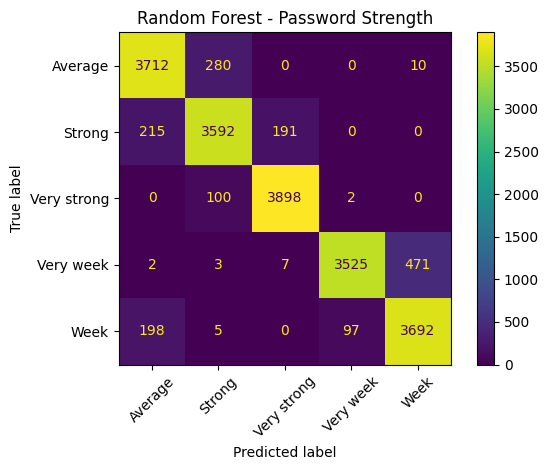

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(xticks_rotation=45)

plt.title("Random Forest - Password Strength")
plt.tight_layout()
plt.show()